In [1]:
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l

# 一个函数
def f(x):
    return 3*x**2-4*x

(**如果$f$的*导数*存在，这个极限被定义为**)

**$$f'(x) = \lim_{h \rightarrow 0} \frac{f(x+h) - f(x)}{h}.$$**

(**定义$u=f(x)=3x^2-4x$**)

In [2]:
#函数的导数
def numerical_lim(f, x, h):
    return (f(x + h) - f(x)) / h
#{var:.nf} 变量是float浮点数，显示n位小数
h = 0.1
for i in range(5):
    print(f'h={h:.5f},numerical limit={numerical_lim(f,1,h):.5f}')
    h*=0.1
    # 不断逼近0，极限也就逼近导数值

h=0.10000,numerical limit=2.30000
h=0.01000,numerical limit=2.03000
h=0.00100,numerical limit=2.00300
h=0.00010,numerical limit=2.00030
h=0.00001,numerical limit=2.00003


In [3]:
def use_svg_display(): #@save
    """使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

In [4]:
def set_figsize(figsize=(3.5, 2.5)):  #@save
    """设置matplotlib的图表大小"""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

In [5]:
#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    # X，Y轴名称
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    # 默认linear线性的
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    # None
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    # 标注
    if legend:
        axes.legend(legend)
    # 显示网格
    axes.grid()

**gca（）**函数用于获取当前图形上与给定关键字 args 匹配的当前 Axes 实例，或者创建一个

**hasattr(obj,key)**
函数是一个内置的实用程序函数，用于检查对象是否具有给定的命名属性，如果存在，则返回 true，否则返回 false。 

**isinstance(object, classinfo)**会认为子类是一种父类类型，考虑继承关系。

**zip（arg[]）**方法采用可迭代或容器并返回单个迭代器对象，该对象具有来自所有容器的映射值。它用于映射多个容器的类似索引，以便仅使用单个实体即可使用它们。

In [6]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,ylim=None, 
xscale='linear', yscale='linear',
fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), 
axes=None):

    """绘制数据点"""
    if legend is None:
        legend = []
    # 设置图像大小
    set_figsize(figsize)
    axes = axes if axes else d2l.plt.gca()

    # 错误检测 如果X有一个轴，输出True。X为单个对象或对象list
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list) and not hasattr(X[0], "__len__"))

    # 处理X，Y轴
    if has_one_axis(X):
        X = [X]
    # y为none则令y=x，x=对应数量的空list
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
        print('Y轴',Y)
    if len(X) != len(Y):
        X = X * len(Y)
    
    # matplotlib 库的 pyplot 模块中的 cla（） 函数用于清除当前轴。
    axes.cla()

    # n个f（x）就遍历 n次，XY为二维列表，xy是一维list，fmt是次要参数
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
            print('X点数量：',len(x))
        else:
            axes.plot(y, fmt)

    # 设置matplotlib轴
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
    
    # XY突然有值，指针？
    # print('X:',X,'\n')
    # print('Y:',Y,'\n')

现在我们可以[**绘制函数$u=f(x)$及其在$x=1$处的切线$y=2x-3$**]，
其中系数$2$是切线的斜率。

X点数量： 30
X点数量： 30


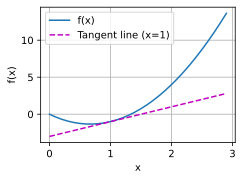

In [7]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

In [8]:
x=[1,2]
y=[3,4,5]
x=x*len(y)
x

[1, 2, 1, 2, 1, 2]

In [9]:
x=[[]]*len(x)
x

[[], [], [], [], [], []]

## 练习

1. 绘制函数$y = f(x) = x^3 - \frac{1}{x}$和其在$x = 1$处切线的图像。
1. 求函数$f(\mathbf{x}) = 3x_1^2 + 5e^{x_2}$的梯度。
1. 函数$f(\mathbf{x}) = \|\mathbf{x}\|_2$的梯度是什么？
1. 尝试写出函数$u = f(x, y, z)$，其中$x = x(a, b)$，$y = y(a, b)$，$z = z(a, b)$的链式法则。

X点数量： 30
X点数量： 30


C:\Users\Raisei\AppData\Local\Temp/ipykernel_33456/1255066659.py:3: RuntimeWarning: divide by zero encountered in true_divide
  return x**3-1/x
C:\Users\Raisei\AppData\Local\Temp/ipykernel_33456/1255066659.py:7: RuntimeWarning: divide by zero encountered in true_divide
  plot(x,[f(x),3*x**2+1/x**2],'x','f(x)',legend=['f(x)','tangent line x=1'])


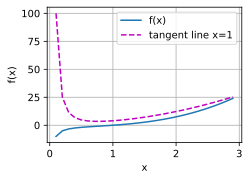

In [10]:
# 1
def f(x):
    return x**3-1/x

x = np.arange(0,3,0.1)

plot(x,[f(x),3*x**2+1/x**2],'x','f(x)',legend=['f(x)','tangent line x=1'])

In [11]:
# 梯度，即总的偏导数
def f(x1,x2):
    return 3*x1**2+5*np.e**x2
def fp(x1,x2):
    return 6*x1+5*np.e**x2


In [12]:
# 3
def L2(x):
    sum = 0
    for i in x:
        sum+=i
    return np.sqrt(sum)

X = np.arange(5)

L2(X)

3.1622776601683795